<div style="display: flex; background-color: RGB(255,114,0);" >
<h1 style="margin: auto; padding: 30px; ">ANALYSE DU STOCK ET DES VENTES DU SITE BOTTLENECK</h1>
</div>

# OBJECTIF DE CE NOTEBOOK

Bienvenue dans l'outil plébiscité par les analystes de données Jupyter.

Il s'agit d'un outil permettant de mixer et d'alterner code, texte et graphiques.

Cet outil est formidable pour plusieurs raisons:

+ Il permet de tester des lignes de codes au fur et à mesure de votre rédaction, de constater immédiatement le résultat d'une instruction, de la corriger si nécessaire.
+ Il permet aussi de rédiger du texte pour expliquer l'approche suivie ou les résultats d'une analyse et de le mettre en forme grâce à du code html ou plus simple avec **Markdown**
+ Il est possible d'ajouter des graphiques

Pour vous aider dans vos premiers pas à l'usage de Jupyter et de Python, nous avons rédigé ce notebook en vous indiquant les instructions à suivre.

Il vous suffit pour cela de saisir le code Python répondant à l'instruction donnée.

Vous verrez de temps à autre le code Python répondant à une instruction donnée mais cela est fait pour vous aider à comprendre la nature du travail qui vous est demandé.

Et gardez à l'esprit qu'il n'y a pas de solution unique pour résoudre un problème et qu'il y a autant de résolutions de problèmes que de développeurs ;)...



<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 1 - Importation des librairies et chargement des fichiers</h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">1.1 - Importation des librairies</h3>
</div>

In [1]:
#Importation de la librairie Pandas
import pandas as pd

In [2]:
#Importation de la librairie plotly express
import plotly.express as px

In [3]:
#Trouver dans Google l'instruction permettant d'afficher toutes les colonnes d'un dataframe
#Saisir dans Google les mots clés "display all columns dataframe Pandas" par exemple.
#Dans les résultats de la recherche, privilégier les solutions provenant de Stack Overflow ou Medium
pd.set_option('display.max_columns', None)

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">1.2 - Chargements des fichiers</h3>
</div>

In [4]:
##### A supprimer

drive = False
if drive:
  from google.colab import drive
  drive.mount('/content/drive')

  df_web = pd.read_excel("/content/drive/MyDrive/Nadia Openclassrooms/Projet 6/test excel/web.xlsx")
  df_erp = pd.read_excel("/content/drive/MyDrive/Nadia Openclassrooms/Projet 6/test excel/erp.xlsx")
  df_liaison = pd.read_excel("/content/drive/MyDrive/Nadia Openclassrooms/Projet 6/test excel/liaison.xlsx")
  print("Les fichiers ont été importés via le Drive")
else:
  #Importation du fichier web.xlsx
  df_web = pd.read_excel("web.xlsx")
  #Importation du fichier erp.xlsx
  df_erp = pd.read_excel("erp.xlsx")
  #Importation du fichier liaison.xlsx
  df_liaison = pd.read_excel("liaison.xlsx")
  print("Les fichiers ont été importés")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Les fichiers ont été importés via le Drive


<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 2 - Analyse exploratoire des fichiers</h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1 - Analyse exploratoire du fichier erp.xlsx</h3>
</div>

In [5]:
#Afficher les dimensions du dataset
print("Le tableau comporte {} observation(s) ou article(s)".format(df_erp.shape[0]))
print("Le tableau comporte {} colonne(s)".format(df_erp.shape[1]))

Le tableau comporte 825 observation(s) ou article(s)
Le tableau comporte 6 colonne(s)


In [6]:
#Consulter le nombre de colonnes
#La nature des données dans chacune des colonnes
#Le nombre de valeurs présentes dans chacune des colonnes
df_erp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 825 entries, 0 to 824
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   product_id      825 non-null    int64  
 1   onsale_web      825 non-null    int64  
 2   price           825 non-null    float64
 3   stock_quantity  825 non-null    int64  
 4   stock_status    825 non-null    object 
 5   purchase_price  825 non-null    float64
dtypes: float64(2), int64(3), object(1)
memory usage: 38.8+ KB


In [7]:
#Afficher les 5 premières lignes de la table
df_erp.head()

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price
0,3847,1,24.2,16,instock,12.88
1,3849,1,34.3,10,instock,17.54
2,3850,1,20.8,0,outofstock,10.64
3,4032,1,14.1,26,instock,6.92
4,4039,1,46.0,3,outofstock,23.77


In [8]:
#Vérifier si il y a des lignes en doublon dans la colonne product_id
doublons = df_erp.duplicated(subset="product_id").sum()
if doublons > 0:
  print("Il y a {} doublons dans la colonne product_id".format(doublons))
  df_erp[df_erp.duplicated(subset="product_id", keep=False)].sort_values(by="product_id")
else:
  print("Il n'y a pas de doublons dans la colonne product_id")

Il n'y a pas de doublons dans la colonne product_id


In [9]:
#Afficher les valeurs distinctes de la colonne stock_status
#À quelle(s) autre(s) colonne(s) sont-elles liées ?
print("Ces valeurs {} de la clonne stock_status sont liées à la colonne stock_quantity".format(df_erp["stock_status"].unique()))

Ces valeurs ['instock' 'outofstock'] de la clonne stock_status sont liées à la colonne stock_quantity


In [10]:
#Création d'une colonne "stock_status_2"
#La valeur de cette deuxième colonne sera fonction de la valeur dans la colonne "stock_quantity"
#Si la valeur de la colonne "stock_quantity" est nulle, renseigner "outofstock" sinon mettre "instock"
def col_stock_status_2(stock_quantity):
    if stock_quantity == 0:
        return "outofstock"
    else:
        return "instock"
df_erp["stock_status_2"] = df_erp["stock_quantity"].apply(col_stock_status_2)
df_erp.columns

Index(['product_id', 'onsale_web', 'price', 'stock_quantity', 'stock_status',
       'purchase_price', 'stock_status_2'],
      dtype='object')

In [11]:
#Vérifions que les 2 colonnes sont identiques:
#Les 2 colonnes sont strictement identiques si les valeurs de chaque ligne sont strictement identiques 2 à 2
#La comparaison de 2 colonnes peut se réaliser simplement avec l'instruction ci-dessous:
comp_col_stocks = df_erp["stock_status"] == df_erp["stock_status_2"]
comp_col_stocks
#Le résultat est l'affichage de True ou False pour chacune des lignes du dataset
#C'est un bon début, mais difficile à exploiter

,0
0,True
1,True
2,True
3,True
4,False
...,...
820,True
821,True
822,True
823,True


In [12]:
#Mais il est possible de synthétiser ce résultat en effectuant la somme de cette colonne:
#True vaut 1 et False 0
#Nous devrions obtenir la somme de 824 qui correspond au nombre de lignes dans ce dataset
print("Il y a {} lignes identiques sur {}".format(comp_col_stocks.sum(), df_erp.shape[0]))

Il y a 821 lignes identiques sur 825


In [13]:
#Si les colonnes ne sont absolument pas identiques ligne à ligne alors identifier la ligne en écart
##Dans ce cas je vous donne ce lien pour apprendre à réaliser des filtres dans Pandas:
##https://bitbucket.org/hrojas/learn-pandas/src/master/
##Lesson 3
verif_incoherences = df_erp["stock_status"] != df_erp["stock_status_2"]
print("Il y a {} lignes qui ne sont pas identiques".format(verif_incoherences.sum()))
df_erp[verif_incoherences]

Il y a 4 lignes qui ne sont pas identiques


,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,stock_status_2
4,4039,1,46.0,3,outofstock,23.77,instock
398,4885,1,18.7,0,instock,9.66,outofstock
449,4973,0,10.0,-10,outofstock,4.96,instock
573,5700,1,44.5,-1,outofstock,22.30,instock


In [14]:
#Corriger la ou les données incohérentes
df_erp.loc[verif_incoherences, "stock_status"] = df_erp["stock_status_2"]
#Vérification en utilisant le même code que plus haut pour afficher les problèmes
comp_col_stocks = df_erp["stock_status"] == df_erp["stock_status_2"]
print("Il y a {} lignes identiques sur {}".format(comp_col_stocks.sum(), df_erp.shape[0]))

Il y a 825 lignes identiques sur 825


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1.1 - Analyse exploratoire de chaque variable du fichier erp.xlsx</h3>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1.1.1 - Analyse de la variable PRIX</h3>
</div>

In [15]:
###############
## LES PRIX  ##
###############

#Vérification des prix: Y a t-il des prix non renseignés, négatifs ou nuls?
#Afficher le ou les prix non renseignés dans la colonne "price"
print("Nombres d'articles avec un prix non renseigné: {}".format(df_erp["price"].isna().sum())) #Saisir l'instruction manquante dans la fonction format
#Afficher le prix minimum de la colonne "price"
print("Le prix minimum renseigné: {}".format(df_erp["price"].min()))
#Afficher le prix maximum de la colonne "price"
print("Le prix maximum renseigné: {}".format(df_erp["price"].max()))
#Afficher les prix inférieurs à 0 (qu'est-ce qu'il faut en faire ?)
print("Nombres d'articles avec un prix inférieur à 0: {}".format((df_erp["price"] < 0).sum()))
df_erp[df_erp["price"] < 0]

Nombres d'articles avec un prix non renseigné: 0
Le prix minimum renseigné: -20.0
Le prix maximum renseigné: 225.0
Nombres d'articles avec un prix inférieur à 0: 3


,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,stock_status_2
151,4233,0,-20.0,0,outofstock,10.33,outofstock
469,5017,0,-8.0,0,outofstock,4.34,outofstock
739,6594,0,-9.1,19,instock,4.61,instock


In [16]:
print("On applique la valeur absolue pour retrouver le prix réel.")
df_erp["price"] = df_erp["price"].abs()
print("Le prix minimum renseigné: {}".format(df_erp["price"].min()))

On applique la valeur absolue pour retrouver le prix réel.
Le prix minimum renseigné: 5.2


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1.1.2 - Analyse de la variable STOCK</h3>
</div>

In [17]:
#######################
### stock_quantity  ###
#######################

#Vérification de la colonne stock quantity
#Afficher la quantité minimum de la colonne "stock_quantity"
print("Quantité minimum renseignée: {}".format(df_erp["stock_quantity"].min()))
#Afficher la quantité maximum de la colonne "stock_quantity"
print("Quantité maximum renseignée: {}".format(df_erp["stock_quantity"].max()))
#Afficher les stocks inférieurs à 0 (qu'est-ce qu'il faut en faire ?)
print("Stock inférieur à 0: {}".format((df_erp["stock_quantity"] < 0).sum()))

Quantité minimum renseignée: -10
Quantité maximum renseignée: 145
Stock inférieur à 0: 2


In [18]:
print("On applique la valeur absolue pour retrouver le stock réel.")
df_erp["stock_quantity"] = df_erp["stock_quantity"].abs()
print("Quantité minimum renseignée: {}".format(df_erp["stock_quantity"].min()))

On applique la valeur absolue pour retrouver le stock réel.
Quantité minimum renseignée: 0


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1.1.3 - Analyse de la variable ONSALE_WEB</h3>
</div>

In [19]:
#Vérification de la colonne onsale_web et des valeurs qu'elle contient. Que signifient-elles?
print("Valeurs présentes dans la colonne onsale_web: {}".format(df_erp["onsale_web"].unique()))
print("Le 1 correspond aux articles en vente sur le site")
print("Le 0 correspond aux articles qui ne le sont pas")

Valeurs présentes dans la colonne onsale_web: [1 0]
Le 1 correspond aux articles en vente sur le site
Le 0 correspond aux articles qui ne le sont pas


In [20]:
#Quelles sont les colonnes à conserver selon vous?
print("Les colonnes à conserver sont toutes les colonnes d'origine sauf stock status_2")

Les colonnes à conserver sont toutes les colonnes d'origine sauf stock status_2


In [21]:
#Supprimer la colonne comportant le libellé "stock_status_2" car elle est redondante
#avec la colonne "stock_status".
df_erp = df_erp.drop(columns="stock_status_2", errors="ignore")
df_erp.columns

Index(['product_id', 'onsale_web', 'price', 'stock_quantity', 'stock_status',
       'purchase_price'],
      dtype='object')

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1.1.4 - Analyse de la variable prix d'achat</h3>
</div>

In [22]:
######################
##   prix d'achat   ##
######################

#Vérification de la colonne purchase_price :
#Afficher le ou les prix non renseignés dans la colonne "purchase_price"
df_erp[df_erp["purchase_price"].isna()]
print("Tout les prix sont renseignés dans la colonne 'purchase_price'")

#Afficher le prix minimum de la colonne "purchase_price"
print("Le prix minimum renseigné: {}".format(df_erp["purchase_price"].min()))

#Afficher le prix maximum de la colonne "purchase_price"
print("Le prix maximum renseigné: {}".format(df_erp["purchase_price"].max()))

Tout les prix sont renseignés dans la colonne 'purchase_price'
Le prix minimum renseigné: 2.74
Le prix maximum renseigné: 137.81


In [23]:
df_erp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 825 entries, 0 to 824
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   product_id      825 non-null    int64  
 1   onsale_web      825 non-null    int64  
 2   price           825 non-null    float64
 3   stock_quantity  825 non-null    int64  
 4   stock_status    825 non-null    object 
 5   purchase_price  825 non-null    float64
dtypes: float64(2), int64(3), object(1)
memory usage: 38.8+ KB


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.2 - Analyse exploratoire du fichier web.xlsx</h3>
</div>


In [24]:
#Dimension du dataset
print("Le tableau comporte {} observation(s) ou article(s)".format(df_web.shape[0]))
print("Le tableau comporte {} colonne(s)".format(df_web.shape[1]))
#Nombre d'observations

#Nombre de caractéristiques


Le tableau comporte 1513 observation(s) ou article(s)
Le tableau comporte 29 colonne(s)


In [25]:
#Consulter le nombre de colonnes
#La nature des données dans chacune des colonnes
#Le nombre de valeurs présentes dans chacune des colonnes
df_web.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1513 entries, 0 to 1512
Data columns (total 29 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   sku                    1428 non-null   object        
 1   virtual                1513 non-null   int64         
 2   downloadable           1513 non-null   int64         
 3   rating_count           1513 non-null   int64         
 4   average_rating         1430 non-null   float64       
 5   total_sales            1430 non-null   float64       
 6   tax_status             716 non-null    object        
 7   tax_class              0 non-null      float64       
 8   post_author            1430 non-null   float64       
 9   post_date              1430 non-null   datetime64[ns]
 10  post_date_gmt          1430 non-null   datetime64[ns]
 11  post_content           0 non-null      float64       
 12  product_type           1429 non-null   object        
 13  pos

In [26]:
#Selon vous, quelles sont les colonnes à conserver ?
col_true = ['sku', 'total_sales', 'tax_status', 'post_author', 'post_date', 'post_date_gmt', 'product_type', 'post_title', 'post_excerpt', 'post_name', 'post_modified', 'post_modified_gmt', 'guid', 'post_type']
print("Les colonnes à conserver sont celles qui contiennent des données distinctes.")

Les colonnes à conserver sont celles qui contiennent des données distinctes.


In [27]:
#Si vous avez défini des colonnes à supprimer, effectuer l'opération
df_web = df_web[col_true]
print("Il y désormais", df_web.shape[1],"colonnes\n", df_web.columns.tolist())

Il y désormais 14 colonnes
 ['sku', 'total_sales', 'tax_status', 'post_author', 'post_date', 'post_date_gmt', 'product_type', 'post_title', 'post_excerpt', 'post_name', 'post_modified', 'post_modified_gmt', 'guid', 'post_type']


In [28]:
#Visualisation des valeurs de la colonne sku
pblm_val_sku = df_web[df_web["sku"].apply(lambda x: not isinstance(x, int))]
print("Il y a {} valeurs qui ne sont pas des entiers dans la colonne sku".format(pblm_val_sku.shape[0]))
#Quelles sont les valeurs qui ne semblent pas respecter la régle de codification?
print("Ces valeurs sont {}".format(pblm_val_sku["sku"].unique()))

Il y a 89 valeurs qui ne sont pas des entiers dans la colonne sku
Ces valeurs sont [nan '13127-1' 'bon-cadeau-25-euros']


In [29]:
#Si vous avez identifié des codes articles ne respectant pas la régle de codification, consultez-les
pblm_val_sku_sans_nan = pblm_val_sku[pblm_val_sku["sku"].notna()]
print(" {} codes articles ne respectent pas la régle de codification".format(pblm_val_sku_sans_nan.shape[0]))
pblm_val_sku_sans_nan.head()

 4 codes articles ne respectent pas la régle de codification


,sku,total_sales,tax_status,post_author,post_date,post_date_gmt,product_type,post_title,post_excerpt,post_name,post_modified,post_modified_gmt,guid,post_type
272,13127-1,4.0,taxable,2.0,2020-06-09 15:42:04,2020-06-09 13:42:04,Vin,Clos du Mont-Olivet Châteauneuf-du-Pape 2007,"Nez gracieux, très élégant avec une touche flo...",clos-du-mont-olivet-chateauneuf-du-pape-2007-2,2020-07-20 17:09:06,2020-07-20 15:09:06,https://www.bottle-neck.fr/?post_type=product&...,product
842,bon-cadeau-25-euros,7.0,NaN,1.0,2018-06-01 13:53:46,2018-06-01 11:53:46,Autre,Bon cadeau de 25€,NaN,bon-cadeau-de-25-euros,2018-06-01 14:13:57,2018-06-01 12:13:57,https://www.bottle-neck.fr/wp-content/uploads/...,attachment
1117,13127-1,4.0,NaN,2.0,2020-06-09 15:42:04,2020-06-09 13:42:04,Vin,Clos du Mont-Olivet Châteauneuf-du-Pape 2007,NaN,clos-du-mont-olivet-chateauneuf-du-pape-2007-2,2020-07-20 17:09:06,2020-07-20 15:09:06,https://www.bottle-neck.fr/wp-content/uploads/...,attachment
1387,bon-cadeau-25-euros,7.0,taxable,1.0,2018-06-01 13:53:46,2018-06-01 11:53:46,NaN,Bon cadeau de 25€,"<span style=""color: #a85253;""><strong>Parlons ...",bon-cadeau-de-25-euros,2018-06-01 14:13:57,2018-06-01 12:13:57,https://www.bottle-neck.fr/?post_type=product&...,product


In [30]:
#Identifier les lignes sans code article
df_web[df_web["sku"].isna()]
print("Il y a {} lignes sans code article".format(df_web["sku"].isna().sum()))

Il y a 85 lignes sans code article


In [31]:
#Pour les codes articles identifiés, réaliser une analyse et définir l'action à entreprendre
print("Les codes articles qui ne respectent pas la règle de codification sont 'bon-cadeau-25-euros' et '13127-1'.")
print("Nous les conserverons car ils contiennent des données de ventes et représentent des produits vendus sur le site.")

Les codes articles qui ne respectent pas la règle de codification sont 'bon-cadeau-25-euros' et '13127-1'.
Nous les conserverons car ils contiennent des données de ventes et représentent des produits vendus sur le site.


In [32]:
#La clé pour chaque ligne est-elle unique? autrement dit, y a-t-il des doublons?
doublons = df_web.duplicated(subset="sku").sum()
print("Il y a {} doublons dans la colonne 'sku'.".format(doublons))
print("Ces doublons apparaissent car certains articles ont deux lignes : une avec post_type='product' et une avec post_type='attachment'.")
print("Nous allons supprimer les lignes avec post_type='attachment' car elles ne contiennent pas de données utiles.")
df_web = df_web[df_web["post_type"] != "attachment"]
print("Après suppression des 'attachment', il reste {} doublons correspondant aux lignes sans code article.".format(df_web.duplicated(subset="sku").sum()))

Il y a 798 doublons dans la colonne 'sku'.
Ces doublons apparaissent car certains articles ont deux lignes : une avec post_type='product' et une avec post_type='attachment'.
Nous allons supprimer les lignes avec post_type='attachment' car elles ne contiennent pas de données utiles.
Après suppression des 'attachment', il reste 84 doublons correspondant aux lignes sans code article.


In [33]:
#Les lignes sans code article semblent être toutes non renseignées
#Pour s'en assurer, réaliser les étapes suivantes:
#1 - Créer un dataframe avec uniquement les lignes sans code article
df_sku_nan = df_web[df_web["sku"].isna()]
#2 - Utiliser la fonction df.info() sur ce nouveau dataframe pour observer le nombre de valeurs renseignées dans chacune des colonnes
df_sku_nan.info()
#3 - Que constatez-vous?
print("On constate que ces 2 lignes sont exploitables, nous allons donc leur attribuer un sku.")

<class 'pandas.core.frame.DataFrame'>
Index: 85 entries, 8 to 1457
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   sku                0 non-null      object        
 1   total_sales        2 non-null      float64       
 2   tax_status         2 non-null      object        
 3   post_author        2 non-null      float64       
 4   post_date          2 non-null      datetime64[ns]
 5   post_date_gmt      2 non-null      datetime64[ns]
 6   product_type       2 non-null      object        
 7   post_title         2 non-null      object        
 8   post_excerpt       2 non-null      object        
 9   post_name          2 non-null      object        
 10  post_modified      2 non-null      datetime64[ns]
 11  post_modified_gmt  2 non-null      datetime64[ns]
 12  guid               2 non-null      object        
 13  post_type          2 non-null      object        
dtypes: datetime64[n

In [34]:
print("On verifie les lignes sans code article qui contiennent tout de même des données.")
df_sku_nan[df_sku_nan.notna().any(axis=1)].head()

On verifie les lignes sans code article qui contiennent tout de même des données.


,sku,total_sales,tax_status,post_author,post_date,post_date_gmt,product_type,post_title,post_excerpt,post_name,post_modified,post_modified_gmt,guid,post_type
1084,NaN,-56.0,taxable,2.0,2018-08-08 11:23:43,2018-08-08 09:23:43,Vin,Pierre Jean Villa Condrieu Jardin Suspendu 2018,"<span id=""u1194-83"">Le nez séduit par ses parf...",pierre-jean-villa-condrieu-suspendu-2018,2019-11-02 13:24:01,2019-11-02 12:24:01,https://www.bottle-neck.fr/?post_type=product&...,product
1087,NaN,-17.0,taxable,2.0,2018-07-31 12:07:23,2018-07-31 10:07:23,Vin,Pierre Jean Villa Côte Rôtie Fongeant 2017,"Fongeant 2017 explose sur un fruit brillant, p...",pierre-jean-villa-cote-rotie-fongeant-2017,2019-11-02 13:24:15,2019-11-02 12:24:15,https://www.bottle-neck.fr/?post_type=product&...,product


In [35]:
print("On leur attribue manuellement un SKU afin de les conserver dans l'analyse.'")
df_web.loc[1084, 'sku'] = 'sans_sku_1'
df_web.loc[1087, 'sku'] = 'sans_sku_2'
df_web.loc[[1084, 1087]]


On leur attribue manuellement un SKU afin de les conserver dans l'analyse.'


,sku,total_sales,tax_status,post_author,post_date,post_date_gmt,product_type,post_title,post_excerpt,post_name,post_modified,post_modified_gmt,guid,post_type
1084,sans_sku_1,-56.0,taxable,2.0,2018-08-08 11:23:43,2018-08-08 09:23:43,Vin,Pierre Jean Villa Condrieu Jardin Suspendu 2018,"<span id=""u1194-83"">Le nez séduit par ses parf...",pierre-jean-villa-condrieu-suspendu-2018,2019-11-02 13:24:01,2019-11-02 12:24:01,https://www.bottle-neck.fr/?post_type=product&...,product
1087,sans_sku_2,-17.0,taxable,2.0,2018-07-31 12:07:23,2018-07-31 10:07:23,Vin,Pierre Jean Villa Côte Rôtie Fongeant 2017,"Fongeant 2017 explose sur un fruit brillant, p...",pierre-jean-villa-cote-rotie-fongeant-2017,2019-11-02 13:24:15,2019-11-02 12:24:15,https://www.bottle-neck.fr/?post_type=product&...,product


In [36]:
print("Les prix étant négatifs, on applique la valeur absolue pour retrouver le prix réel.")
df_web["total_sales"] = df_web["total_sales"].abs()
print("Le prix minimum renseigné: {}".format(df_web["total_sales"].min()))

Les prix étant négatifs, on applique la valeur absolue pour retrouver le prix réel.
Le prix minimum renseigné: 0.0


In [37]:
print("Les 2 articles sans SKU ont un 'product_id' identifiable à la fin de leur URL dans la colonne 'guid'.")
print(df_web.loc[1084, 'guid'])
print(df_web.loc[1087, 'guid'])
print("On leur attribuera les SKU 'sans_sku_1' et 'sans_sku_2' lors du nettoyage du fichier liaison.xlsx.")

Les 2 articles sans SKU ont un 'product_id' identifiable à la fin de leur URL dans la colonne 'guid'.
https://www.bottle-neck.fr/?post_type=product&#038;p=5075
https://www.bottle-neck.fr/?post_type=product&#038;p=5070
On leur attribuera les SKU 'sans_sku_1' et 'sans_sku_2' lors du nettoyage du fichier liaison.xlsx.


In [38]:
print("Nous pouvons supprimer les lignes entièrement vides ainsi que les colonnes 'tax_status' et 'post_type' qui ne contiennent qu'une seule valeur unique et n'apportent aucune information à l'analyse.")
df_web = df_web.dropna(how="all")
df_web = df_web.drop(columns=["tax_status", "post_type"], errors="ignore")
print("Il reste {} lignes et {} colonnes\n".format(df_web.shape[0], df_web.shape[1]))
df_web.info()

Nous pouvons supprimer les lignes entièrement vides ainsi que les colonnes 'tax_status' et 'post_type' qui ne contiennent qu'une seule valeur unique et n'apportent aucune information à l'analyse.
Il reste 716 lignes et 12 colonnes

<class 'pandas.core.frame.DataFrame'>
Index: 716 entries, 2 to 1509
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   sku                716 non-null    object        
 1   total_sales        716 non-null    float64       
 2   post_author        716 non-null    float64       
 3   post_date          716 non-null    datetime64[ns]
 4   post_date_gmt      716 non-null    datetime64[ns]
 5   product_type       715 non-null    object        
 6   post_title         716 non-null    object        
 7   post_excerpt       716 non-null    object        
 8   post_name          716 non-null    object        
 9   post_modified      716 non-null    datetime64[ns]
 10  po

### 2.3 - Analyse exploratoire du fichier liaison.xlsx

In [39]:
#Dimension du dataset
#Nombre d'observations
print("Le tableau comporte {} observation(s) ou article(s)".format(df_liaison.shape[0]))
print("Le tableau comporte {} colonne(s)".format(df_liaison.shape[1]))
#Nombre de caractéristiques

Le tableau comporte 825 observation(s) ou article(s)
Le tableau comporte 2 colonne(s)


In [40]:
#Consulter le nombre de colonnes
#La nature des données dans chacune des colonnes
#Le nombre de valeurs présentes dans chacune des colonnes
df_liaison.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 825 entries, 0 to 824
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   id_web      734 non-null    object
 1   product_id  825 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 13.0+ KB


In [41]:
#Les valeurs de la colonne "product_id" sont-elles toutes uniques?
diff_product_id = df_liaison["product_id"].shape[0] - df_liaison["product_id"].nunique()
if diff_product_id:
  print("La colonne product_id n'est pas unique, elle contient {} doublons".format(diff_product_id))
  if df_liaison["product_id"].isna().sum():
    print("Ces {} valeurs sont des valeurs nulles".format(df_liaison["product_id"].isna().sum()))
else:
    print("La colonne product_id est unique")

La colonne product_id est unique


In [42]:
#Les valeurs de la colonne "id_web" sont-elles toutes uniques?
diff_id_web = df_liaison["id_web"].shape[0] - df_liaison["id_web"].nunique()
if diff_id_web:
  print("La colonne id_web n'est pas unique, elle contient {} doublons".format(diff_id_web))
  if df_liaison["id_web"].isna().sum():
    print("Ces {} valeurs sont des valeurs nulles".format(df_liaison["id_web"].isna().sum()))
else:
    print("La colonne id_web est unique")

La colonne id_web n'est pas unique, elle contient 91 doublons
Ces 91 valeurs sont des valeurs nulles


In [43]:
print("Nous allons vérifier que les product_id 5075 et 5070 existent bien dans le fichier liaison avant de leur attribuer un id_web.")
df_liaison[df_liaison["product_id"].isin([5075, 5070])]

Nous allons vérifier que les product_id 5075 et 5070 existent bien dans le fichier liaison avant de leur attribuer un id_web.


,id_web,product_id
486,NaN,5070
487,NaN,5075


In [44]:
print("Les product_id 5075 et 5070 existent bien dans le fichier liaison avec un id_web NaN. Nous allons donc leur attribuer les id_web 'sans_sku_1' et 'sans_sku_2' créés précédemment dans le fichier web.")
df_liaison.loc[df_liaison["product_id"] == 5075, "id_web"] = "sans_sku_1"
df_liaison.loc[df_liaison["product_id"] == 5070, "id_web"] = "sans_sku_2"
df_liaison[df_liaison["product_id"].isin([5075, 5070])]

Les product_id 5075 et 5070 existent bien dans le fichier liaison avec un id_web NaN. Nous allons donc leur attribuer les id_web 'sans_sku_1' et 'sans_sku_2' créés précédemment dans le fichier web.


,id_web,product_id
486,sans_sku_2,5070
487,sans_sku_1,5075


In [45]:
#Avons-nous des articles sans correspondance?
correspondance_id_product = df_liaison['product_id'].isna().sum()
print("Il y a {} id_product sans correspondance, dont {} valeurs nulles".format(correspondance_id_product, df_liaison["product_id"].isna().sum()))
correspondance_id_web = df_liaison['id_web'].isna().sum()
print("Il y a {} id_web sans correspondance, dont {} valeurs nulles".format(correspondance_id_web, df_liaison["id_web"].isna().sum()))

Il y a 0 id_product sans correspondance, dont 0 valeurs nulles
Il y a 89 id_web sans correspondance, dont 89 valeurs nulles


<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 3 - Jonction des fichiers</h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 3.1 - Jonction du fichier df_erp et df_liaison</h3>
</div>

In [46]:
#Fusion des fichiers df_erp et df_liaison
df_erp_liaison = pd.merge(df_erp, df_liaison, on="product_id", how="outer", indicator= True)
df_erp_liaison.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 825 entries, 0 to 824
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   product_id      825 non-null    int64   
 1   onsale_web      825 non-null    int64   
 2   price           825 non-null    float64 
 3   stock_quantity  825 non-null    int64   
 4   stock_status    825 non-null    object  
 5   purchase_price  825 non-null    float64 
 6   id_web          736 non-null    object  
 7   _merge          825 non-null    category
dtypes: category(1), float64(2), int64(3), object(2)
memory usage: 46.2+ KB


In [47]:
#Y a t-il des lignes ne "matchant" pas entre les 2 fichiers?
match_erp_liaison = df_erp_liaison[df_erp_liaison["_merge"] != "both"]
print("Il y a {} lignes qui ne match pas".format(match_erp_liaison.shape[0]))
df_erp_liaison.head()

Il y a 0 lignes qui ne match pas


,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,id_web,_merge
0,3847,1,24.2,16,instock,12.88,15298,both
1,3849,1,34.3,10,instock,17.54,15296,both
2,3850,1,20.8,0,outofstock,10.64,15300,both
3,4032,1,14.1,26,instock,6.92,19814,both
4,4039,1,46.0,3,instock,23.77,19815,both


In [48]:
print("On supprime la colonne '_merge' qui ne sert plus à rien après vérification de la jointure.\n")
df_erp_liaison.drop(columns="_merge", inplace=True, errors="ignore")
df_erp_liaison.info()

On supprime la colonne '_merge' qui ne sert plus à rien après vérification de la jointure.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 825 entries, 0 to 824
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   product_id      825 non-null    int64  
 1   onsale_web      825 non-null    int64  
 2   price           825 non-null    float64
 3   stock_quantity  825 non-null    int64  
 4   stock_status    825 non-null    object 
 5   purchase_price  825 non-null    float64
 6   id_web          736 non-null    object 
dtypes: float64(2), int64(3), object(2)
memory usage: 45.2+ KB


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 3.2 - Jonction du fichier df_merge et df_web</h3>
</div>

In [49]:
#Fusionner les datasets df_merge et df_web
df_merge = pd.merge(df_erp_liaison, df_web, left_on="id_web", right_on="sku", how="outer", indicator="_merge_2")
df_merge.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 825 entries, 0 to 824
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   product_id         825 non-null    int64         
 1   onsale_web         825 non-null    int64         
 2   price              825 non-null    float64       
 3   stock_quantity     825 non-null    int64         
 4   stock_status       825 non-null    object        
 5   purchase_price     825 non-null    float64       
 6   id_web             736 non-null    object        
 7   sku                716 non-null    object        
 8   total_sales        716 non-null    float64       
 9   post_author        716 non-null    float64       
 10  post_date          716 non-null    datetime64[ns]
 11  post_date_gmt      716 non-null    datetime64[ns]
 12  product_type       715 non-null    object        
 13  post_title         716 non-null    object        
 14  post_excer

In [50]:
#Avons-nous des lignes sans correspondance?
match_all = df_merge[df_merge["_merge_2"] != "both"]
print("Il y a {} lignes qui ne match pas".format(match_all.shape[0]))
match_all.head(10)

Il y a 109 lignes qui ne match pas


,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,id_web,sku,total_sales,post_author,post_date,post_date_gmt,product_type,post_title,post_excerpt,post_name,post_modified,post_modified_gmt,guid,_merge_2
81,4741,0,12.4,0,outofstock,6.66,12601,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaT,NaT,NaN,left_only
127,5957,0,39.0,0,outofstock,20.75,13577,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaT,NaT,NaN,left_only
139,4289,0,22.8,0,outofstock,11.90,13771,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaT,NaT,NaN,left_only
180,4869,0,17.2,0,outofstock,9.33,14360,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaT,NaT,NaN,left_only
185,5955,0,27.3,0,outofstock,13.68,14377,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaT,NaT,NaN,left_only
186,5953,0,47.5,0,outofstock,23.81,14379,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaT,NaT,NaN,left_only
212,5505,0,10.1,0,outofstock,5.22,14648,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaT,NaT,NaN,left_only
218,5800,0,32.3,0,outofstock,16.02,14689,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaT,NaT,NaN,left_only
224,5559,0,27.9,3,instock,13.98,14715,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaT,NaT,NaN,left_only
227,5570,0,22.5,0,outofstock,11.16,14730,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaT,NaT,NaN,left_only


In [51]:
print("Parmi les {} lignes sans correspondance :".format(match_all.shape[0]))
print(" - {} articles sans id_web (pas d'équivalent web dans le fichier liaison)".format(match_all["id_web"].isna().sum()))
print(" - {} articles avec id_web mais absents du fichier web (articles supprimés ou format non standard)".format(match_all["id_web"].notna().sum()))
print("On décide de conserver ces lignes car elles contiennent des données utiles pour l'analyse des stocks, des prix et des prix d'achat, même si elles n'ont pas de correspondance dans le fichier web.")

Parmi les 109 lignes sans correspondance :
 - 89 articles sans id_web (pas d'équivalent web dans le fichier liaison)
 - 20 articles avec id_web mais absents du fichier web (articles supprimés ou format non standard)
On décide de conserver ces lignes car elles contiennent des données utiles pour l'analyse des stocks, des prix et des prix d'achat, même si elles n'ont pas de correspondance dans le fichier web.


In [52]:
print("On supprime la colonne '_merge_2' qui ne sert plus à rien après vérification de la jointure\n")
df_merge.drop(columns="_merge_2", inplace=True, errors="ignore")
df_merge.info()

On supprime la colonne '_merge_2' qui ne sert plus à rien après vérification de la jointure

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 825 entries, 0 to 824
Data columns (total 19 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   product_id         825 non-null    int64         
 1   onsale_web         825 non-null    int64         
 2   price              825 non-null    float64       
 3   stock_quantity     825 non-null    int64         
 4   stock_status       825 non-null    object        
 5   purchase_price     825 non-null    float64       
 6   id_web             736 non-null    object        
 7   sku                716 non-null    object        
 8   total_sales        716 non-null    float64       
 9   post_author        716 non-null    float64       
 10  post_date          716 non-null    datetime64[ns]
 11  post_date_gmt      716 non-null    datetime64[ns]
 12  product_type       715 non-

<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 4 - Analyse univariée des prix</h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 4.1 - Exploration par la visualisation de données</h3>
</div>

<Axes: title={'center': 'Répartition des prix €'}>

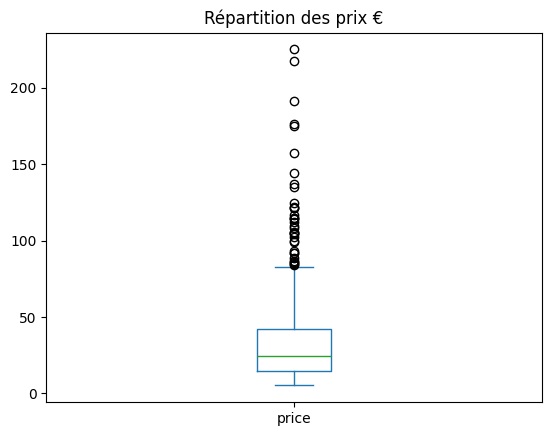

In [53]:
#Création d'une boîte à moustache de la répartition des prix grâce à Pandas
df_merge["price"].plot.box(title="Répartition des prix €")

In [54]:
#Autre méthode avec plotly express
fig = px.box(df_merge, y="price", title="Répartition des prix €")
fig.show()

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 4.2 - Exploration par l'utilisation de méthodes statistiques</h3>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 4.2.1 - Identification par le Z-index</h3>
</div>

In [55]:
#Calculer la moyenne du prix
moyenne_prix = df_merge["price"].mean()
print("La moyenne des prix est de {}€".format(round(moyenne_prix,2)))
#Calculer l'écart-type du prix
ecart_type_prix = df_merge["price"].std()
print("L'écart-type des prix est de {}€".format(round(ecart_type_prix,2)))
#Calculer le Z-score
df_merge["z_score"] = (df_merge["price"] - moyenne_prix) / ecart_type_prix
df_merge['z_score'].head(10)

La moyenne des prix est de 32.28€
L'écart-type des prix est de 26.6€


,z_score
0,-0.890030
1,0.327869
2,0.252690
3,1.038310
4,-0.367536
5,1.673572
6,1.132284
7,1.132284
8,0.275244
9,0.756389


In [56]:
#Quel est le seuil prix dont le z-score est supérieur à 3?
print("Le seuil prix dont le z-score est supérieur à 3 est de {}€".format(round(df_merge[df_merge["z_score"] > 3]["price"].min(), 2)))

Le seuil prix dont le z-score est supérieur à 3 est de 114.0€


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 4.2.2 - Identification par l'intervalle interquartile</h3>
</div>

In [57]:
#Utilisation de la fonction "describe" de Pandas pour l'étude des mesures de dispersion
description = df_merge["price"].describe()
print(description)

count    825.000000
mean      32.277636
std       26.603196
min        5.200000
25%       14.500000
50%       24.300000
75%       42.000000
max      225.000000
Name: price, dtype: float64


In [58]:
#Définir un seuil pour les articles "outliers" en prix
Q1 = df_merge["price"].quantile(0.25)
Q3 = df_merge["price"].quantile(0.75)
IQR = Q3-Q1
seuil_min = Q1 - 1.5*IQR
seuil_max = Q3 + 1.5*IQR
print("Les articles dont le prix est superieur à {}€ seront considérés comme des outliers".format(seuil_max))


Les articles dont le prix est superieur à 83.25€ seront considérés comme des outliers


In [59]:
#Définir le nombre d'articles et la proportion de l'ensemble du catalogue "outliers"
print("Il y a {} articles qui sont considérés comme des outliers".format(df_merge[(df_merge["price"] < seuil_min) | (df_merge["price"] > seuil_max)].shape[0]))

Il y a 36 articles qui sont considérés comme des outliers


In [60]:
#Selon vous, ces outliers sont-ils justifiés ? Comment le démontrer si cela est possible ?
outliers = df_merge[df_merge["price"] > seuil_max]
outliers[["price", "post_title", "product_type"]].sort_values("price", ascending=False)
print("Les {} outliers sont des articles dont le prix dépasse 83.25€.".format(outliers.shape[0]))
print("Ces prix élevés sont justifiés car il s'agit de produits rares et haut de gamme donc assez couteux.")
print("La répartition par type de produit :\n")
print(outliers["product_type"].value_counts())

Les 36 outliers sont des articles dont le prix dépasse 83.25€.
Ces prix élevés sont justifiés car il s'agit de produits rares et haut de gamme donc assez couteux.
La répartition par type de produit :

product_type
Vin          20
Champagne     6
Cognac        4
Whisky        3
Name: count, dtype: int64


<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 5 - Analyse univariée du CA, des quantités vendues, des stocks et de la marge ainsi qu'une analyse multivariée  </h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.1 - Analyse des ventes en CA</h3>
</div>

In [61]:
##############################
# Calculer le CA du site web #
##############################

#Créer une colonne calculant le CA par article
df_merge["ca_par_article"] = df_merge["price"] * df_merge["total_sales"]

#Calculer la somme de la colonne "ca_par_article"
CA = df_merge["ca_par_article"].sum()
print("Le CA pour le mois d'octobre est de {} €".format(round(CA,2)))

#Ce résultat correspond au chiffre d'affaire du site web
CA_onsale = df_merge[df_merge["onsale_web"] == 1]["ca_par_article"].sum()
print("Le CA pour le mois d'octobre vente sur le site est de {}€".format(round(CA_onsale, 2)))
print("La différence de {}€ provient d'un article qui n'est plus en vente sur le site mais qui apparaît dans le fichier web, probablement retiré de la vente en cours du mois d'octobre.".format(round(CA - CA_onsale,2)))
df_merge[(df_merge["onsale_web"] == 0) & (df_merge["total_sales"] > 0)]

Le CA pour le mois d'octobre est de 147544.8 €
Le CA pour le mois d'octobre vente sur le site est de 147463.6€
La différence de 81.2€ provient d'un article qui n'est plus en vente sur le site mais qui apparaît dans le fichier web, probablement retiré de la vente en cours du mois d'octobre.


,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,id_web,sku,total_sales,post_author,post_date,post_date_gmt,product_type,post_title,post_excerpt,post_name,post_modified,post_modified_gmt,guid,z_score,ca_par_article
682,4200,0,5.8,33,instock,3.12,16295,16295,14.0,2.0,2018-02-15 14:05:06,2018-02-15 13:05:06,Vin,Moulin de Gassac IGP Pays d'Hérault Guilhem Ro...,"Rosé très agréable, intense, floral et minéral...",moulin-de-gassac-igp-pays-dherault-guilhem-ros...,2020-08-27 18:55:03,2020-08-27 16:55:03,https://www.bottle-neck.fr/?post_type=product&...,-0.99528,81.2


In [62]:
###############################
# Palmarès des articles en CA #
###############################

#Effectuer le tri dans l'ordre décroissant du CA du dataset df_merge
df_merge.sort_values(by="ca_par_article", ascending=False, inplace=True)

#Réinitialiser l'index du dataset par un reset_index
df_merge.reset_index(drop=True, inplace=True)
#Afficher les 20 premiers articles en CA
df_merge.head(20)
#Graphique en barre des 20 premiers articles avec plotly express
fig = px.bar(df_merge.head(20), x="post_title", y="ca_par_article", text="ca_par_article", title="Palmarès des articles en CA", hover_data={"ca_par_article": ":.2f"})
fig.update_traces(texttemplate="%{text:.0f}€", textposition="inside")
fig.show()

In [63]:
#############################
# Calculer le 20 / 80 en CA #
#############################

#Créer une colonne calculant la part du CA de la ligne dans le dataset
df_merge["part_ca"] = df_merge["ca_par_article"] / CA
#Créer une colonne réalisant la somme cumulative de la colonne précedemment créée
df_merge["cum_part_ca"] = df_merge["part_ca"].cumsum()
#Grâce aux deux colonnes créées précedemment, calculer le nombre d'articles représentant 80% du CA
nb_articles_80_ca = df_merge[df_merge["cum_part_ca"] <= 0.8].shape[0]
print("Il y a {} articles qui représentent 80% du CA".format(nb_articles_80_ca))
#Afficher la proportion que représente ce groupe d'articles dans le catalogue entier du site web
proportion_80_ca = nb_articles_80_ca * 100 / df_merge.shape[0]
print("La proportion que représente ce groupe d'articles dans le catalogue entier du site web est de {}%".format(round(proportion_80_ca,2)))

Il y a 430 articles qui représentent 80% du CA
La proportion que représente ce groupe d'articles dans le catalogue entier du site web est de 52.12%


In [64]:
fig = px.line(df_merge, y="cum_part_ca", title="Courbe cumulative du CA (Loi de Pareto)", labels={"index": "Nombre d'articles", "cum_part_ca": "Part cumulée du CA"})
fig.add_hline(y=0.8, line_dash="dash", line_color="red", annotation_text="80% du CA")
fig.add_vline(x=df_merge.shape[0]*0.2, line_dash="dash", line_color="blue", annotation_text="20% des articles")
fig.show()

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.2 - Analyse des ventes en quantité</h3>
</div>

In [65]:
#####################################
# Palmarès des articles en quantité #
#####################################

#Effectuer le tri dans l'ordre décroissant de quantités vendues du dataset df_merge
df_merge.sort_values(by="total_sales", ascending=False, inplace=True)
#Réinitialiser l'index du dataset par un reset_index
df_merge.reset_index(drop=True, inplace=True)
#Afficher les 20 premiers articles en quantité
df_merge.head(20)
#Graphique en barre des 20 premiers articles avec plotly express
fig = px.bar(df_merge.head(20), x="post_title", y="total_sales", text="total_sales", title="Top 20 des articles les plus vendus", labels={"post_title": "Article", "total_sales": "Quantité vendue"})
fig.update_traces(texttemplate="%{text}", textposition="inside")
fig.show()

In [66]:
#############################
# Calculer le 20 / 80 en CA #
#############################

#Créer une colonne calculant la part en quantité de la ligne dans le dataset
df_merge["part_quantite"] = df_merge["total_sales"] / df_merge["total_sales"].sum()
#Créer une colonne réalisant la somme cumulative de la colonne précedemment créée
df_merge["cum_part_quantite"] = df_merge["part_quantite"].cumsum()
#Grâce aux deux colonnes créées précedemment, calculer le nombre d'articles représentant 80% des ventes en quantité
nb_articles_80_quantite = df_merge[df_merge["cum_part_quantite"] <= 0.8].shape[0]
print("Il y a {} articles qui représentent 80% des ventes en quantité".format(nb_articles_80_quantite))
#Afficher la proportion que représente ce groupe d'articles dans le catalogue entier du site web
proportion_80_quantite = nb_articles_80_quantite * 100 / df_merge.shape[0]
print("La proportion que représente ce groupe d'articles dans le catalogue entier du site web est de {}%".format(round(proportion_80_quantite,2)))

Il y a 433 articles qui représentent 80% des ventes en quantité
La proportion que représente ce groupe d'articles dans le catalogue entier du site web est de 52.48%


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.3 - Analyse des stocks</h3>
</div>

In [69]:
######################################
# Calculer le nombre de mois de stock #
######################################

#Import de numpy
import numpy as np
#Création de la colonne Rotation de stock
df_merge["rotation_stock"] = df_merge["stock_quantity"] / df_merge["total_sales"]
#Remplacement des "inf" par 0
df_merge["rotation_stock"] = df_merge["rotation_stock"].replace([np.inf, -np.inf], 0)
#Effectuer le tri dans l'ordre décroissant du nombre de mois de stock dans le dataset df_merge
df_merge.sort_values(by="rotation_stock", ascending=False, inplace=True)
#Réinitialiser l'index du dataset par un reset_index
df_merge.reset_index(drop=True, inplace=True)
#Graphique en barre du flop 20 des produits qui ont le plus de mois de stock
fig = px.bar(df_merge.head(20), x="post_title", y="rotation_stock", text="rotation_stock", title="Flop 20 des produits qui ont le plus de mois de stock", labels={"post_title": "Article", "rotation_stock": "Nombre de mois de stock"})
fig.update_traces(texttemplate="%{text:.1f}", textposition="inside")
fig.show()

In [70]:
# Articles avec stock mais aucune vente
invendus = df_merge[(df_merge["stock_quantity"] > 0) & (df_merge["total_sales"] == 0)]
print("Articles en stock mais pas vendus :", invendus.shape[0])
invendus[["post_title", "stock_quantity", "purchase_price","product_type"]].sort_values("stock_quantity", ascending=False)

Articles en stock mais pas vendus : 3


,post_title,stock_quantity,purchase_price,product_type
691,Champagne Mailly Grand Cru Les Echansons 2007,145,48.90,Champagne
692,Champagne Egly-Ouriet Grand Cru Blanc de Noirs,97,77.48,Champagne
693,Cognac Normandin Mercier VFC,13,27.18,Cognac


In [71]:
df_merge.head(20)[["post_title", "price", "product_type","stock_quantity","total_sales", "rotation_stock"]]

,post_title,price,product_type,stock_quantity,total_sales,rotation_stock
0,Champagne Gosset Grand Millésime 2006,53.0,Champagne,125,4.0,31.250000
1,Champagne Gosset Célébris Vintage 2007,135.0,Champagne,138,5.0,27.600000
2,Champagne Egly-Ouriet Premier Cru Les Vignes d...,51.6,Champagne,81,3.0,27.000000
3,Champagne Egly-Ouriet Grand Cru Brut Tradition,59.0,Champagne,125,5.0,25.000000
4,Champagne Mailly Grand Cru Brut Rosé,37.5,Champagne,71,3.0,23.666667
5,Champagne Larmandier-Bernier Latitude,39.0,Champagne,115,5.0,23.000000
6,Champagne Gosset Grand Rosé,49.0,Champagne,91,4.0,22.750000
7,Champagne Agrapart &amp; Fils L'Avizoise Extra...,112.0,Champagne,136,6.0,22.666667
8,Champagne Egly-Ouriet Grand Cru Extra Brut V.P.,79.5,Champagne,145,7.0,20.714286
9,Champagne Mailly Grand Cru Intemporelle 2010,59.0,Champagne,123,6.0,20.500000


In [72]:
####################################
# Valorisation des stocks en euros #
####################################

#Création de la colonne Valorisation des stocks en euros
df_merge["valorisation_stock_euros"] = df_merge["stock_quantity"] * df_merge["purchase_price"]
#Calculer la somme de la colonne "Valorisation_stock_euros"
print("La valeur de stock est de {}€".format(round(df_merge["valorisation_stock_euros"].sum(),2)))

La valeur de stock est de 298699.56€


In [73]:
##############################################
# Valorisation du nombre de produits en stock #
##############################################

#Calculer la somme de la colonne stock quantity
som_quant_stock = int(df_merge["stock_quantity"].sum())
print("Le nombre de produits en stock est de {}".format(som_quant_stock))

Le nombre de produits en stock est de 17833


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.4 - Analyse du taux de marge</h3>
</div>

In [74]:
############################
# Analyse du taux de marge #
############################

#Création de la colonne Prix HT
df_merge["prix_ht"] = df_merge["price"] / 1.2
#Création de la colonne Taux de marge
df_merge["taux_marge"] = ((df_merge["prix_ht"] - df_merge["purchase_price"]) / df_merge["prix_ht"]) * 100
#Afficher le prix minimum de la colonne "taux_marge"
print("Le taux de marge minimum est de {:.2f}%".format(df_merge["taux_marge"].min()))
#Afficher le prix maximum de la colonne "taux_marge"
print("Le taux de marge maximum est de {:.2f}%".format(df_merge["taux_marge"].max()))

Le taux de marge minimum est de -634.99%
Le taux de marge maximum est de 47.76%


In [75]:
#Affichage de la ligne avec un taux de marge inférieur à 0
df_merge[df_merge["taux_marge"] < 0]

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,id_web,sku,total_sales,post_author,post_date,post_date_gmt,product_type,post_title,post_excerpt,post_name,post_modified,post_modified_gmt,guid,z_score,ca_par_article,part_ca,cum_part_ca,part_quantite,cum_part_quantite,rotation_stock,valorisation_stock_euros,prix_ht,taux_marge
692,4355,1,12.65,97,instock,77.48,12589,12589,0.0,2.0,2018-03-02 10:46:10,2018-03-02 09:46:10,Champagne,Champagne Egly-Ouriet Grand Cru Blanc de Noirs,Le Blanc de Noirs représente le meilleur du sa...,champagne-egly-ouriet-grand-cru-brut-blanc-de-...,2020-08-13 10:15:02,2020-08-13 08:15:02,https://www.bottle-neck.fr/?post_type=product&...,-0.737792,0.0,0.0,1.0,0.0,1.0,0.0,7515.56,10.541667,-634.988142
728,4864,0,8.30,0,outofstock,9.99,15154,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaT,NaT,NaN,-0.901307,NaN,NaN,NaN,NaN,NaN,NaN,0.00,6.916667,-44.433735
770,6324,0,92.00,18,instock,99.00,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaT,NaT,NaN,2.244932,NaN,NaN,NaN,NaN,NaN,NaN,1782.00,76.666667,-29.130435
820,7196,0,31.00,55,instock,31.20,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaT,NaT,NaN,-0.048026,NaN,NaN,NaN,NaN,NaN,NaN,1716.00,25.833333,-20.774194


In [76]:
#Création d'un dataframe avec les taux positifs
df_merge_marge_pos = df_merge[df_merge["taux_marge"] > 0]
#Afficher le prix minimum de la colonne "taux_marge"
print("Le taux de marge minimum est de {:.2f}%".format(df_merge_marge_pos["taux_marge"].min()))
#Afficher le prix maximum de la colonne "taux_marge"
print("Le taux de marge maximum est de {:.2f}%".format(df_merge_marge_pos["taux_marge"].max()))

Le taux de marge minimum est de 22.78%
Le taux de marge maximum est de 47.76%


In [77]:
#Création d'un dataframe avec le taux de marge moyen par type de produit
df_taux_marge_moy = df_merge.groupby("product_type")["taux_marge"].mean().sort_values(ascending=False)
#Affichage dans un graphique du taux de marge par type de produit
fig = px.bar(df_taux_marge_moy, x=df_taux_marge_moy.index, y=df_taux_marge_moy.values, text=df_taux_marge_moy.values, title="Taux de marge par type de produit", labels={"x": "Type de produit", "y": "Taux de marge moyen (%)"})
fig.update_traces(texttemplate="%{text:.2f}%", textposition="inside")
fig.show()

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.5 - Analyse des corrélations entre les variables stock, sales et price</h3>
</div>

<Axes: >

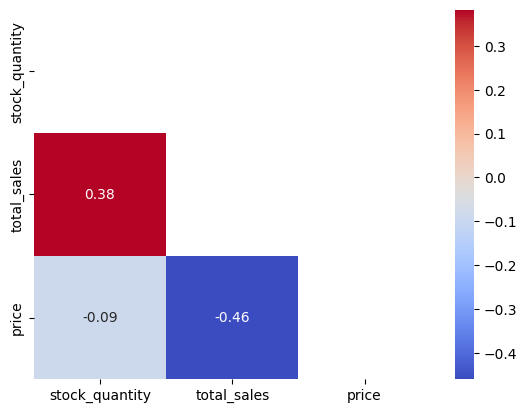

In [90]:
############################
# Analyse des corrélations #
############################

#Importation de Seaborn
import seaborn as sns
#Création d'une heatmap de corrélation avec les variables stock, sales et price
#sns.heatmap(df_merge[["stock_quantity", "total_sales", "price"]].corr(), annot=True)
#On peut également créer un mask pour n'afficher qu'une demi heatmap
mask = np.triu(np.ones_like(df_merge[["stock_quantity", "total_sales", "price"]].corr()))
sns.heatmap(df_merge[["stock_quantity", "total_sales", "price"]].corr(), mask=mask, annot=True, cmap="coolwarm")

<Axes: >

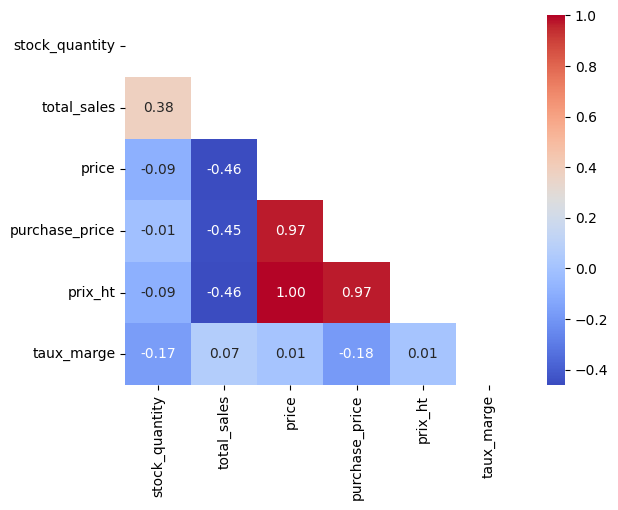

In [88]:
# Heatmap complète
colonnes = ["stock_quantity", "total_sales", "price", "purchase_price", "prix_ht", "taux_marge"]
mask = np.triu(np.ones_like(df_merge[colonnes].corr()))
sns.heatmap(df_merge[colonnes].corr(), mask=mask, annot=True, cmap="coolwarm", fmt=".2f")

In [ ]:
#Que peut-on conclure des corrélations ?
print("Stock et ventes (0.38) :plus un produit a du stock, plus il a tendance à se vendre")
print("Prix et ventes (-0.46) :Plus un article est cher, moins il est vendu.")
print("Stock et prix (-0.09) :Le prix n'influence pas le stock.")

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.6 - Mise à disposition de la nouvelle table sur un fichier Excel</h3>
</div>

In [91]:
#Mettre le dataset df_merge sur un fichier Excel
#Cette étape peut être utile pour partager le résultat du dataset obtenu avec les équipes.
from google.colab import files

df_merge.to_excel("df_merge.xlsx", index=False)
files.download("df_merge.xlsx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>